# Explore a trained encoder

Load an encoder checkpoint, visualize the similarity grid, plot the
unique radius polar, and run a few navigation trajectories.

Most of the logic lives in `encoder_training/{viz,trajectory,evaluate}.py`
— this notebook just glues things together.


In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NB_DIR, '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from encoder_training.train import load_encoder
from encoder_training.data import build_full_grid
from encoder_training.evaluate import encode_grid
from encoder_training import viz, trajectory

## 1 · Load encoder and encode the full grid

In [49]:
# CKPT = '/home/jackking/cls/encoders/binary_20260420_183304/encoder_best.pt'
# CKPT = "/home/jackking/cls/encoders/binary_20260409_083227/encoder_final.pt"
CKPT = "/home/jackking/cls/encoders/run_20260421_204648/encoder_best.pt"

encoder, ckpt = load_encoder(CKPT)
device = next(encoder.parameters()).device
gain   = float(ckpt['gain'])
lambdas = ckpt['model_config']['lambdas']
y0s = ckpt['y0s']; x0s = ckpt['x0s']; sizes = ckpt['sizes']
fwhm = (ckpt.get('train_config') or {}).get('fwhm_ratio', 0.25)

print(f'Lambdas={lambdas}  gain={gain}  n_envs={len(sizes)}  '
      f'sizes={sorted(set(sizes))}')
if 'val_nav_acc' in ckpt:
    print(f'Saved peak val_nav_acc: {ckpt["val_nav_acc"]:.3f}')

Phi_full, full_Npos = build_full_grid(lambdas, fwhm_ratio=fwhm)
print(f'Encoding {full_Npos}x{full_Npos} grid...')
Z = encode_grid(encoder, Phi_full, gain, device)   # (H, W, D)
print('Encoded shape:', Z.shape)

Lambdas=[11, 12, 13]  gain=2.996661101836394  n_envs=25  sizes=[100]
Saved peak val_nav_acc: 0.958
Encoding 1716x1716 grid...
Encoded shape: (1716, 1716, 256)


## Place-field-style feature maps

Each panel shows one coordinate of the encoded vector **across space** (like the spatial receptive field of one hidden unit). Set **`VIEW_SIDE`** to zoom; use **`HIGHPASS_SIGMA`** (wide Gaussian subtracted) to emphasize local peaks vs slow background; set **`IMSHOW_VMAX_PCTL`** (e.g. `99`) so the colormap ignores hot outliers. Blur / rectification still help when channels are signed or noisy.

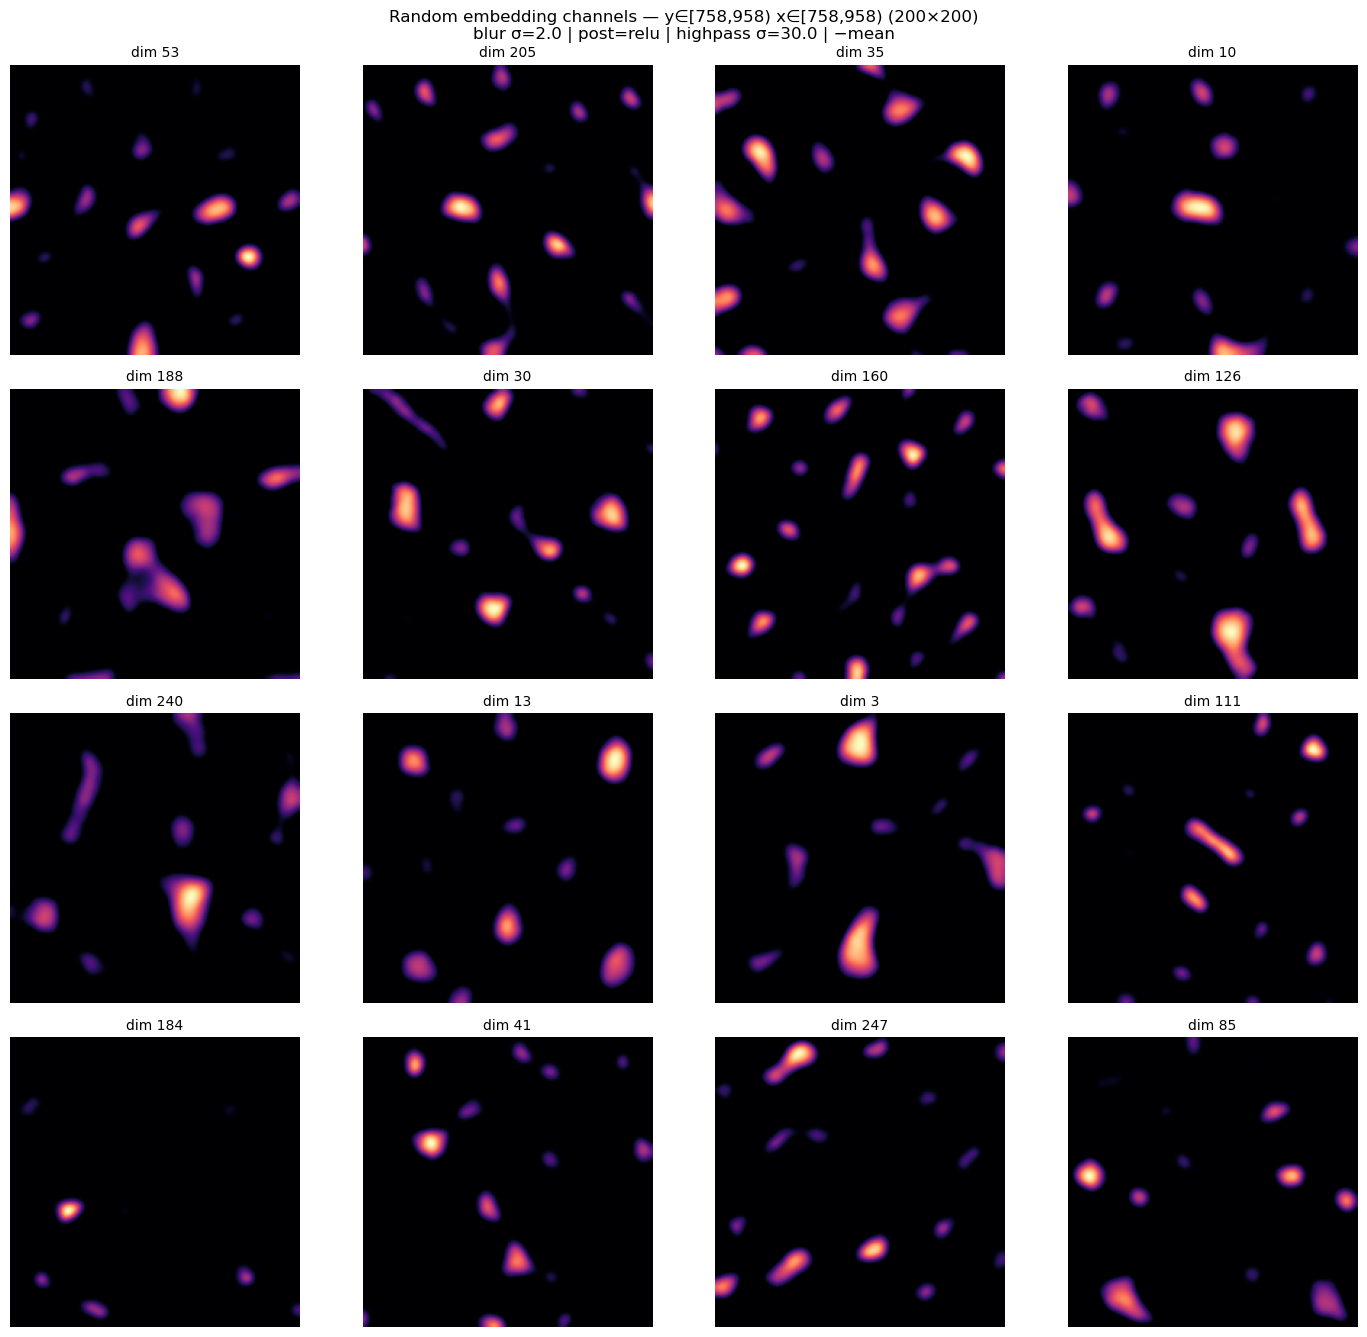

In [85]:
from scipy.ndimage import gaussian_filter

# --- knobs: tweak to bring out localized bumps ---
PLACECELL_SEED = 2
N_FEATURES = 16          # how many random embedding dims to plot
VIEW_SIDE = 200         # None = full grid; else square window side length (cells)
VIEW_CENTER_YX = None    # None = grid center; else (row, col) center of that window
BLUR_SIGMA = 2.0         # Gaussian blur in grid cells; set 0 to disable
POSTPROCESS = "relu"     # "none" | "relu" | "abs" | "square" | "softplus"
RELU_THRESH = 0.08       # threshold for ReLU
SUBTRACT_GLOBAL_MEAN = True
NORMALIZE_EACH = False    # per-map min–max to [0, 1] after processing
HIGHPASS_SIGMA = 30.0     # subtract Gaussian(x,σ); 0 = off. Wide σ (e.g. 8–30) removes slow background
IMSHOW_VMIN_PCTL = None  # used only if IMSHOW_VMAX_PCTL is set; None → vmin=0
IMSHOW_VMAX_PCTL = None  # e.g. 99.0 = colormap vmax at 99th percentile; None → auto vmax

Z_full = np.asarray(Z)
H_full, W_full, D = Z_full.shape
if VIEW_SIDE is None:
    y0, x0, Z_np = 0, 0, Z_full
    H, W = H_full, W_full
    roi_note = "full grid"
else:
    s = int(min(int(VIEW_SIDE), H_full, W_full))
    cy = VIEW_CENTER_YX[0] if VIEW_CENTER_YX is not None else H_full // 2
    cx = VIEW_CENTER_YX[1] if VIEW_CENTER_YX is not None else W_full // 2
    y0 = int(np.clip(cy - s // 2, 0, H_full - s))
    x0 = int(np.clip(cx - s // 2, 0, W_full - s))
    Z_np = Z_full[y0 : y0 + s, x0 : x0 + s, :]
    H, W = Z_np.shape[0], Z_np.shape[1]
    roi_note = f"y∈[{y0},{y0 + s}) x∈[{x0},{x0 + s})"

rng = np.random.RandomState(PLACECELL_SEED)
n_show = min(N_FEATURES, D)
inds = rng.choice(D, size=n_show, replace=False)


def placefield_map(channel_2d: np.ndarray) -> np.ndarray:
    x = channel_2d.astype(np.float64, copy=False)
    if SUBTRACT_GLOBAL_MEAN:
        x = x - float(x.mean())
    if POSTPROCESS == "relu":
        x = np.maximum(RELU_THRESH, x)
    elif POSTPROCESS == "abs":
        x = np.abs(x)
    elif POSTPROCESS == "square":
        x = x * x
    elif POSTPROCESS == "softplus":
        z = np.clip(x, -20.0, 20.0)
        x = np.log1p(np.exp(z))
    elif POSTPROCESS != "none":
        raise ValueError(f"unknown POSTPROCESS={POSTPROCESS!r}")
    if HIGHPASS_SIGMA and HIGHPASS_SIGMA > 0:
        x = x - gaussian_filter(x, sigma=float(HIGHPASS_SIGMA))
    if BLUR_SIGMA and BLUR_SIGMA > 0:
        x = gaussian_filter(x, sigma=float(BLUR_SIGMA))
    if NORMALIZE_EACH:
        mn, mx = float(x.min()), float(x.max())
        if mx > mn:
            x = (x - mn) / (mx - mn)
        else:
            x = np.zeros_like(x)
    return x


n_cols = 4
n_rows = int(np.ceil(n_show / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 3.4 * n_rows))
axes = np.atleast_2d(axes)
for i, d in enumerate(inds):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]
    m = placefield_map(Z_np[:, :, d])
    if IMSHOW_VMAX_PCTL is not None:
        vmax = float(np.percentile(m, IMSHOW_VMAX_PCTL))
        if IMSHOW_VMIN_PCTL is not None:
            vmin = float(np.percentile(m, IMSHOW_VMIN_PCTL))
        else:
            vmin = 0.0
        if vmax <= vmin:
            vmax = vmin + 1e-12
    else:
        vmin, vmax = 0.0, (1.0 if NORMALIZE_EACH else None)
    ax.imshow(m, cmap="magma", origin="upper", vmin=vmin, vmax=vmax)
    ax.set_title(f"dim {d}", fontsize=10)
    ax.axis("off")
for j in range(n_show, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis("off")
subtitle = (
    f"blur σ={BLUR_SIGMA} | post={POSTPROCESS}"
    + (f" | highpass σ={HIGHPASS_SIGMA}" if HIGHPASS_SIGMA and HIGHPASS_SIGMA > 0 else "")
    + (" | −mean" if SUBTRACT_GLOBAL_MEAN else "")
    + (" | norm" if NORMALIZE_EACH else "")
    + (
        f" | imshow pctl lo={IMSHOW_VMIN_PCTL} hi={IMSHOW_VMAX_PCTL}"
        if IMSHOW_VMAX_PCTL is not None
        else ""
    )
)
fig.suptitle(
    f"Random embedding channels — {roi_note} ({H}×{W})\n{subtitle}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 2 · Training environments

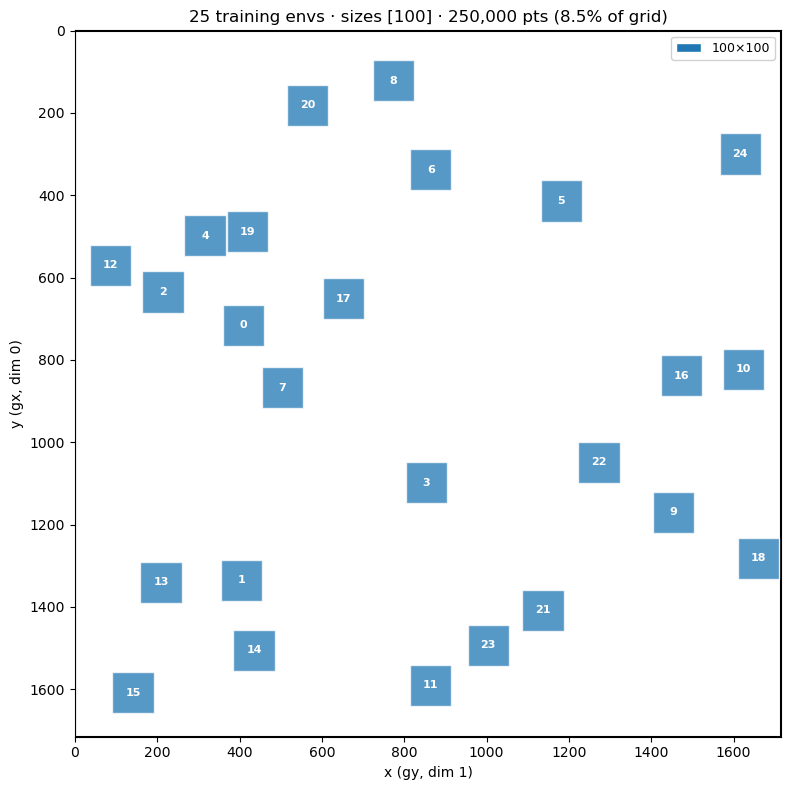

In [50]:
# Show the patches the encoder was trained on, overlaid on the full grid.
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-0.5, full_Npos - 0.5)
ax.set_ylim(full_Npos - 0.5, -0.5)    # image convention: origin top-left
ax.set_aspect('equal')
ax.add_patch(plt.Rectangle((0, 0), full_Npos, full_Npos,
                           fill=False, edgecolor='black', linewidth=1.5))

# Colour patches by size so mixed-Npos runs are easy to read.
unique_sizes = sorted(set(sizes))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(unique_sizes), 3)))
size_to_color = {s: cmap[i % len(cmap)] for i, s in enumerate(unique_sizes)}

for i, (y0, x0, s) in enumerate(zip(y0s, x0s, sizes)):
    ax.add_patch(plt.Rectangle((x0, y0), s, s,
                                facecolor=size_to_color[s], edgecolor='white',
                                linewidth=1.0, alpha=0.75))
    ax.text(x0 + s / 2, y0 + s / 2, str(i),
            ha='center', va='center', fontsize=8,
            fontweight='bold', color='white')

total_pts = int(sum(s * s for s in sizes))
coverage = 100 * total_pts / (full_Npos * full_Npos)
ax.set_title(f'{len(sizes)} training envs · '
             f'sizes {unique_sizes} · '
             f'{total_pts:,} pts ({coverage:.1f}% of grid)')
ax.set_xlabel('x (gy, dim 1)')
ax.set_ylabel('y (gx, dim 0)')

# Legend by patch size
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=size_to_color[s],
                         edgecolor='white', label=f'{s}×{s}')
           for s in unique_sizes]
ax.legend(handles=handles, loc='upper right', framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

## 3 · Similarity heatmap

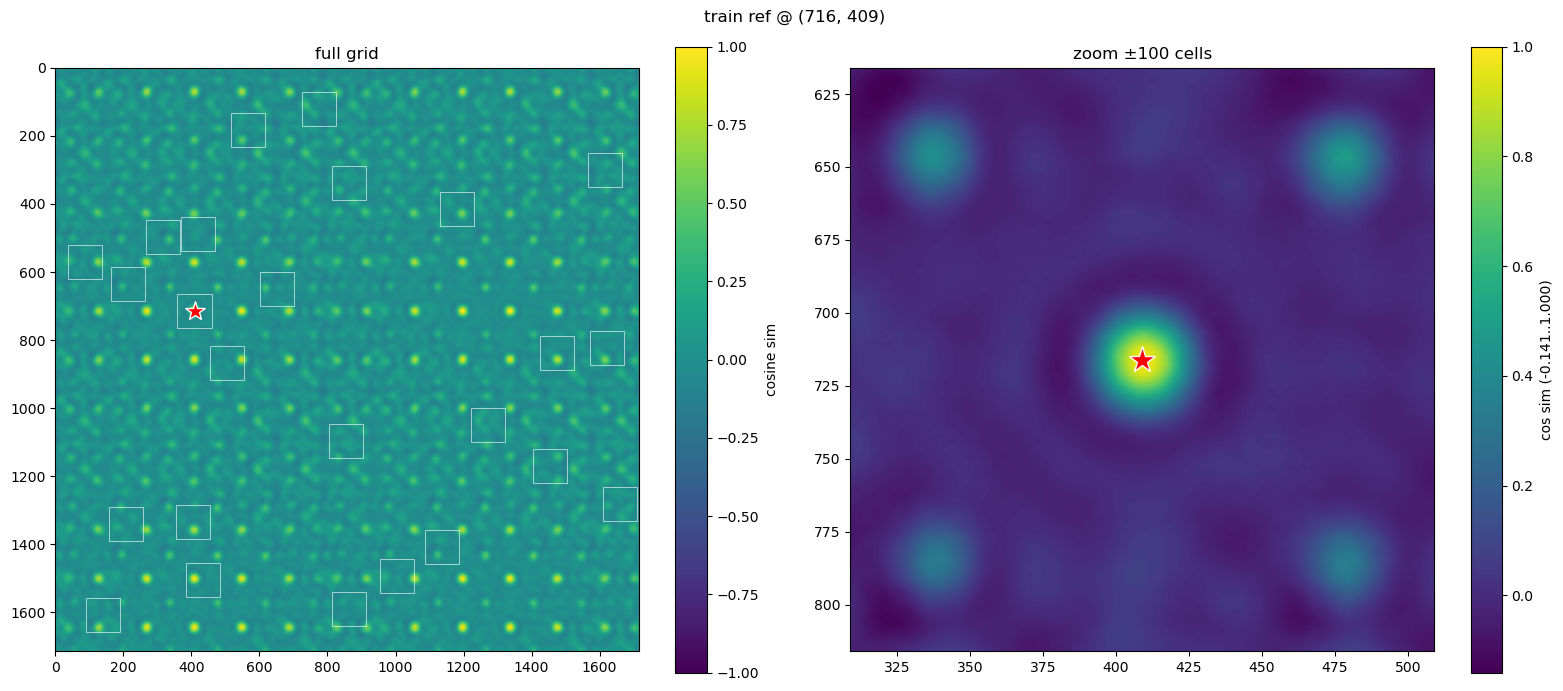

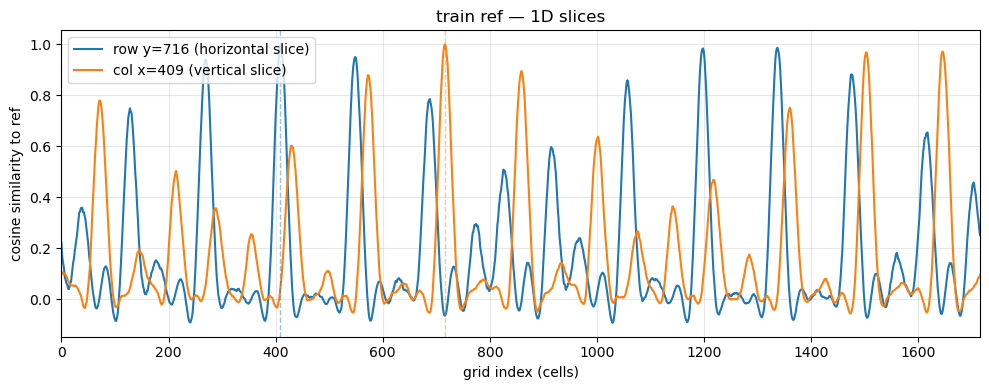

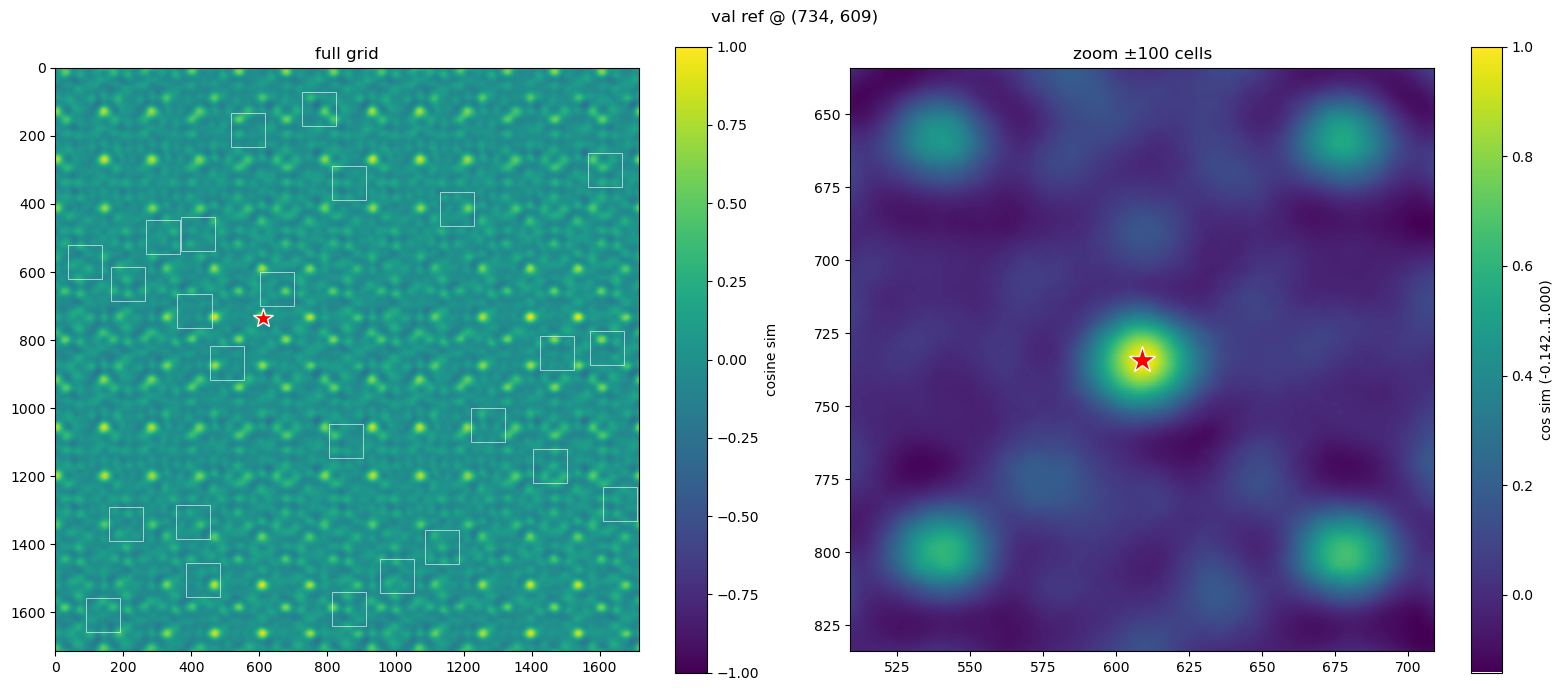

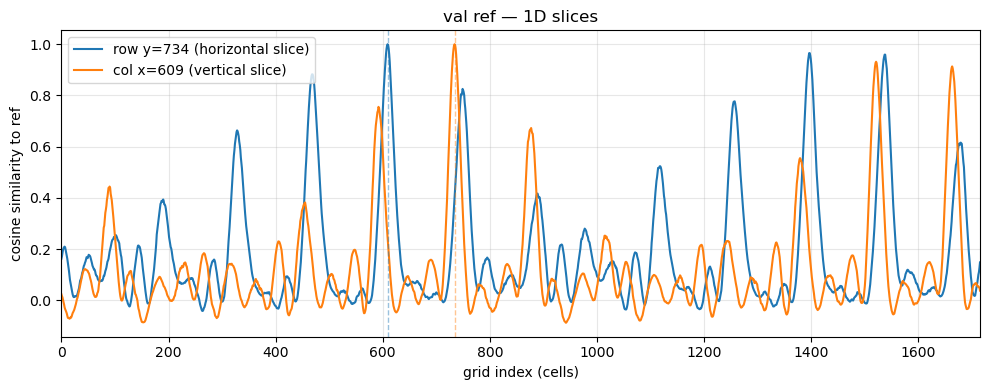

In [55]:
# Pick a reference point inside a training patch (and one outside) to contrast.
ref_train = (y0s[0] + sizes[0] // 2, x0s[0] + sizes[0] // 2)

def _first_outside(n=1000):
    rng = np.random.RandomState(0)
    for _ in range(n):
        y = int(rng.randint(50, full_Npos - 50))
        x = int(rng.randint(50, full_Npos - 50))
        if not any(y0 <= y < y0 + s and x0 <= x < x0 + s
                   for y0, x0, s in zip(y0s, x0s, sizes)):
            return (y, x)
    raise RuntimeError('no outside point found')

ref_val = _first_outside()

for kind, (ry, rx) in [('train', ref_train), ('val', ref_val)]:
    cos_map = viz.plot_similarity_heatmap(
        Z, ref_x=rx, ref_y=ry,
        y0s=y0s, x0s=x0s, sizes=sizes,
        title=f'{kind} ref @ ({ry}, {rx})',
    )
    plt.show()

    # 1D slices through the reference: fixed row ry (vary x) and fixed col rx (vary y)
    H, W = cos_map.shape
    xs = np.arange(W)
    ys = np.arange(H)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(xs, cos_map[ry, :], label=f'row y={ry} (horizontal slice)')
    ax.plot(ys, cos_map[:, rx], label=f'col x={rx} (vertical slice)')
    ax.axvline(rx, color='C0', ls='--', alpha=0.45, linewidth=1)
    ax.axvline(ry, color='C1', ls='--', alpha=0.45, linewidth=1)
    ax.set_xlabel('grid index (cells)')
    ax.set_ylabel('cosine similarity to ref')
    ax.set_title(f'{kind} ref — 1D slices')
    ax.legend(loc='best')
    ax.set_xlim(0, max(H, W) - 1)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4 · Unique-radius polar plot

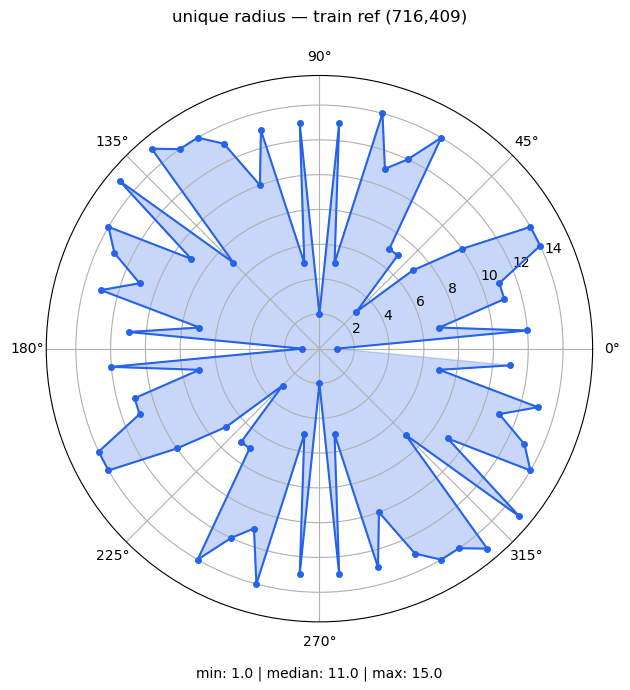

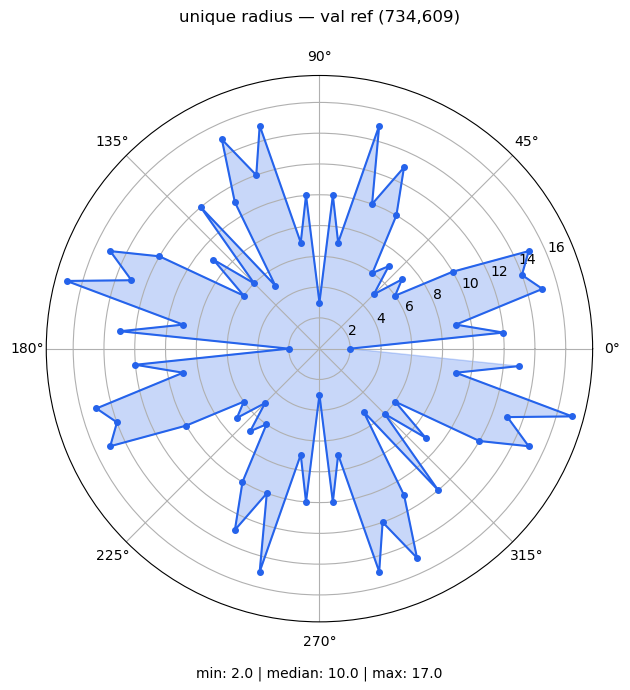

In [54]:
for kind, (ry, rx) in [('train', ref_train), ('val', ref_val)]:
    cos_map = viz.similarity_map(Z, rx, ry)
    thetas, widths = viz.unique_radius_per_theta(cos_map, rx, ry, n_rays=72)
    viz.plot_unique_radius_polar(thetas, widths,
                                  title=f'unique radius — {kind} ref ({ry},{rx})')
    plt.show()

## 5 · Trajectory visualizations

Place a few validation environments outside training patches, seed a
Hopfield with their goal embeddings, and roll out continuous trajectories.

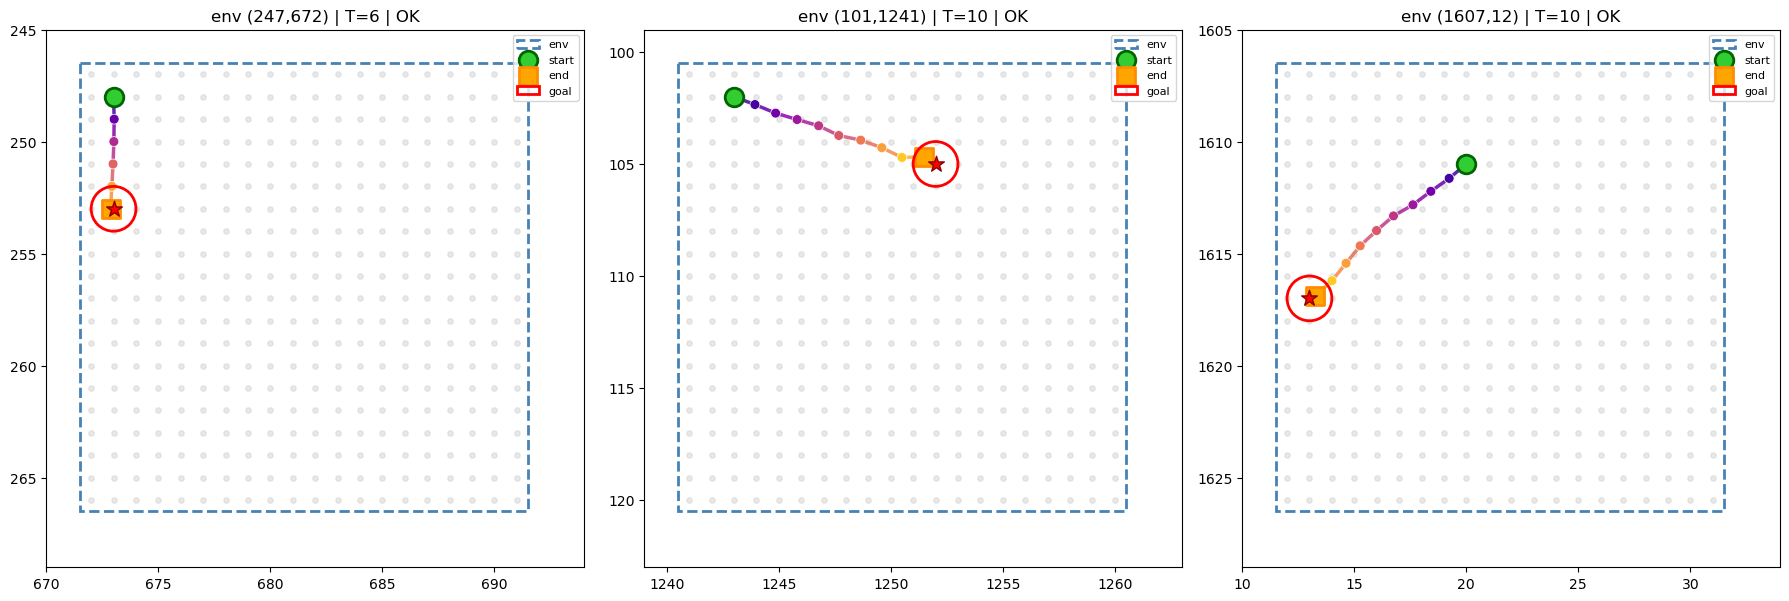

In [53]:
# Fresh envs every run. Pass rng=np.random.RandomState(seed) to lock.
placements = trajectory.place_random_envs(
    full_Npos=full_Npos, n_envs=3, env_size=20,
    avoid=list(zip(y0s, x0s, sizes)),
)
envs = trajectory.build_eval_envs(placements, env_size=20)
hop = trajectory.build_hopfield(Z, envs, gain)

fig, axes = plt.subplots(1, len(envs), figsize=(6 * len(envs), 6))
if len(envs) == 1:
    axes = [axes]
for env, ax in zip(envs, axes):
    # Random start inside the env, different from the goal
    while True:
        sy = int(np.random.randint(env.y0, env.y0 + env.size))
        sx = int(np.random.randint(env.x0, env.x0 + env.size))
        if (sy, sx) != (env.goal_gx, env.goal_gy):
            break
    traj, angles, mags = trajectory.simulate_trajectory(
        Z, hop, env, start_gx=sy, start_gy=sx, gain=gain,
        max_steps=60, scale=1.0, normalize=True, platform_radius=1.0,
    )
    ended_at_goal = np.linalg.norm(traj[-1] - [env.goal_gx, env.goal_gy]) < 1.0
    trajectory.plot_trajectory(env, traj, angles=angles, ax=ax,
                               title=f'env ({env.y0},{env.x0}) | '
                                     f'T={len(traj)} | '
                                     f"{'OK' if ended_at_goal else 'MISS'}")
plt.tight_layout()
plt.show()